In [3]:
import pandas as pd

pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import List
from pyprojroot import here


In [5]:
data_path = here("Data/FPL_data_untidy.parquet")
data = pd.read_parquet(data_path,
                       engine='pyarrow')
data.columns = data.columns.str.lower()
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,mng_clean_sheets,mng_draw,mng_goals_scored,mng_loss,mng_underdog_draw,mng_underdog_win,mng_win,modified,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles
0,Eric Bailly,DEF,Man Utd,0.0,0,0,0,0,0.0,286,6,0,0,0.0,0.0,2021-08-14T11:30:00Z,0,10,0,0,0,0,1,0,9363,1,5,0.0,0,0,0,0,50,True,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,Keinan Davis,FWD,Aston Villa,0.4,0,0,0,0,0.0,49,8,0,0,0.0,0.0,2021-08-14T14:00:00Z,0,18,0,0,0,0,1,0,169789,2,3,0.0,0,0,0,0,45,False,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
2,Ayotomiwa Dele-Bashiru,MID,Watford,0.0,0,0,0,0,0.0,394,8,0,0,0.0,0.0,2021-08-14T14:00:00Z,0,2,0,0,0,0,1,0,4092,2,3,0.0,0,0,0,0,45,True,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
3,James Ward-Prowse,MID,Southampton,2.3,0,0,20,0,30.5,341,4,3,0,5.2,21.6,2021-08-14T14:00:00Z,90,8,0,0,0,0,1,0,299682,1,3,0.0,2,0,0,0,65,False,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,Bruno Miguel Borges Fernandes,MID,Man Utd,4.4,0,3,61,0,35.9,277,6,1,3,20.1,106.2,2021-08-14T11:30:00Z,90,10,0,0,0,0,1,0,3381004,1,5,59.0,20,0,0,0,120,True,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN


In [6]:
data.isna().sum().sum()

np.int64(1444306)

In [7]:
data.isna().mean()[data.isna().mean()>0]

expected_assists                   0.199639
expected_goal_involvements         0.199639
expected_goals                     0.199639
expected_goals_conceded            0.199639
starts                             0.199639
mng_clean_sheets                   0.894661
mng_draw                           0.894661
mng_goals_scored                   0.894661
mng_loss                           0.894661
mng_underdog_draw                  0.894661
mng_underdog_win                   0.894661
mng_win                            0.894661
modified                           0.640780
clearances_blocks_interceptions    0.857349
defensive_contribution             0.857349
recoveries                         0.857349
tackles                            0.857349
dtype: float64

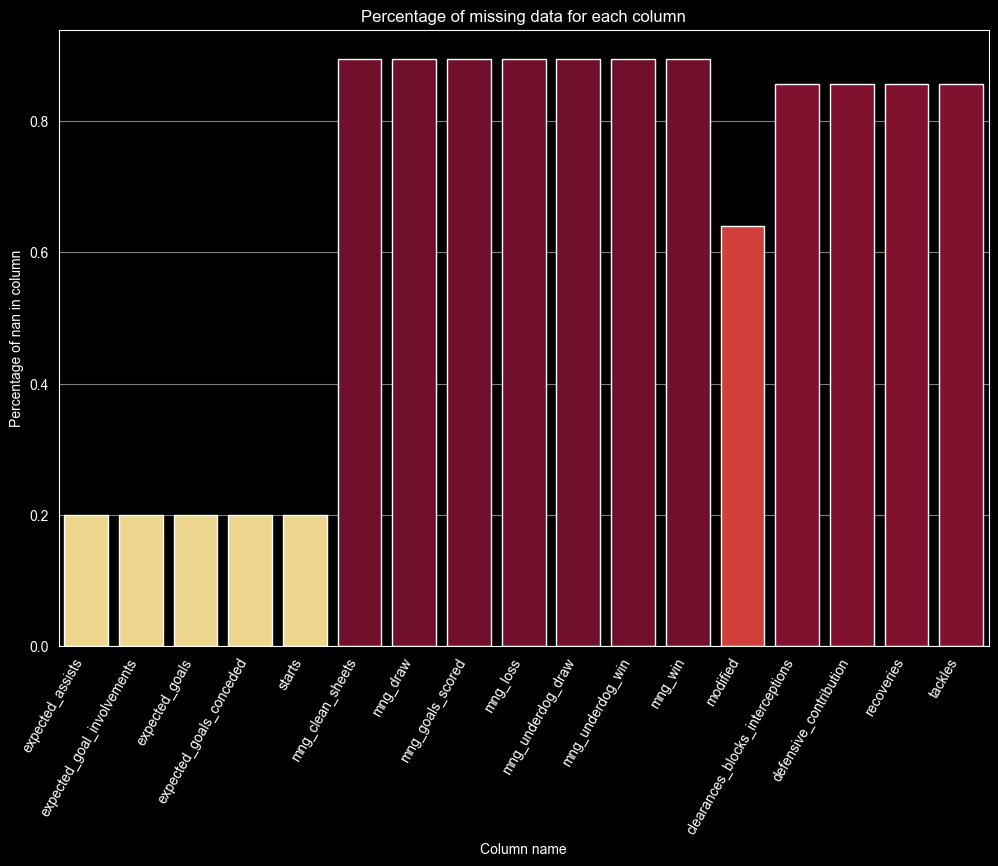

In [8]:
plt.figure(figsize=(12, 8))
s = data.isna().mean()
s = s[s > 0]

sns.barplot(x=s.index, y=s, hue=s.index, legend=False, palette=list(plt.cm.YlOrRd((s / s.max()))))
plt.xlabel("Column name")
plt.ylabel("Percentage of nan in column")
plt.title("Percentage of missing data for each column")

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.5);

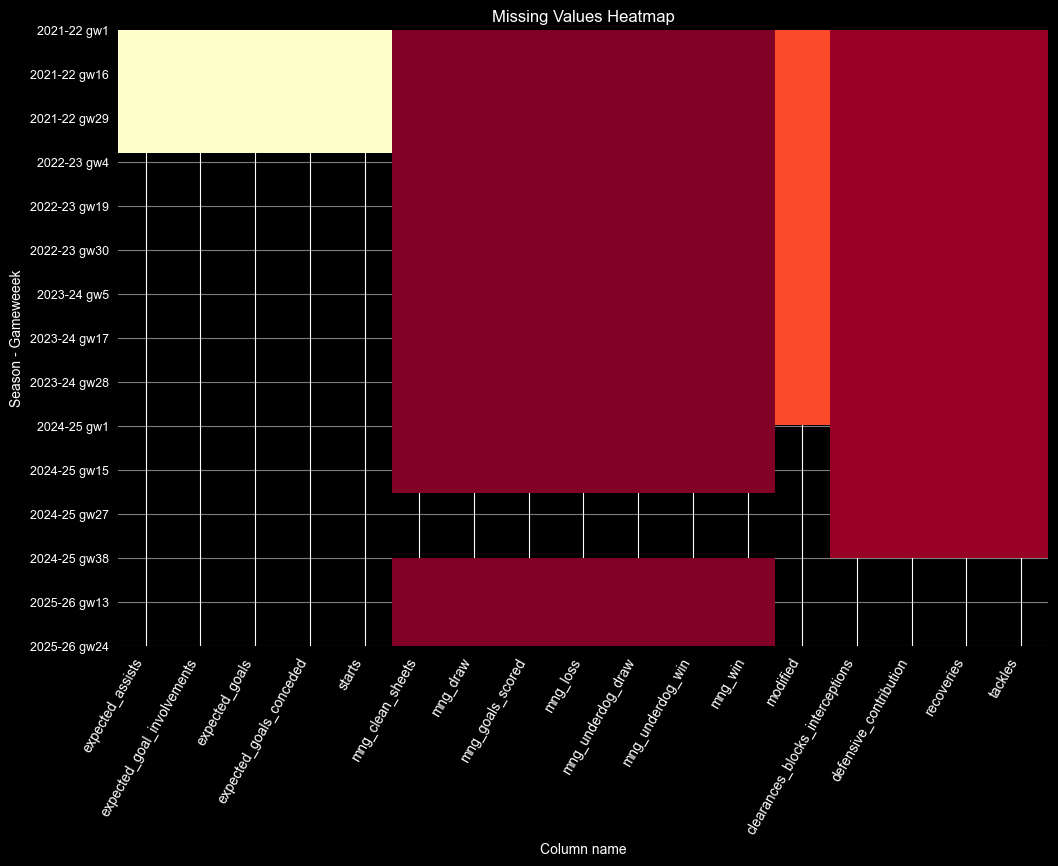

In [9]:
d = data.loc[:, data.isna().any()]
labels = data["season_id"].astype(str) + " gw" + data["gw"].astype(str)
plt.figure(figsize=(12, 8))
sns.heatmap(d.isna() * d.isna().mean(), mask=d.notna(), cmap='YlOrRd',
            cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.xticks(rotation=60, ha='right')

n_ticks = 15
y_positions = np.linspace(0, d.shape[0]-1, n_ticks)

plt.yticks(y_positions, labels.iloc[y_positions.astype(int)], fontsize=9)
plt.ylabel("Season - Gameweeek")
plt.xlabel("Column name")

plt.grid(axis='y', alpha=0.5)

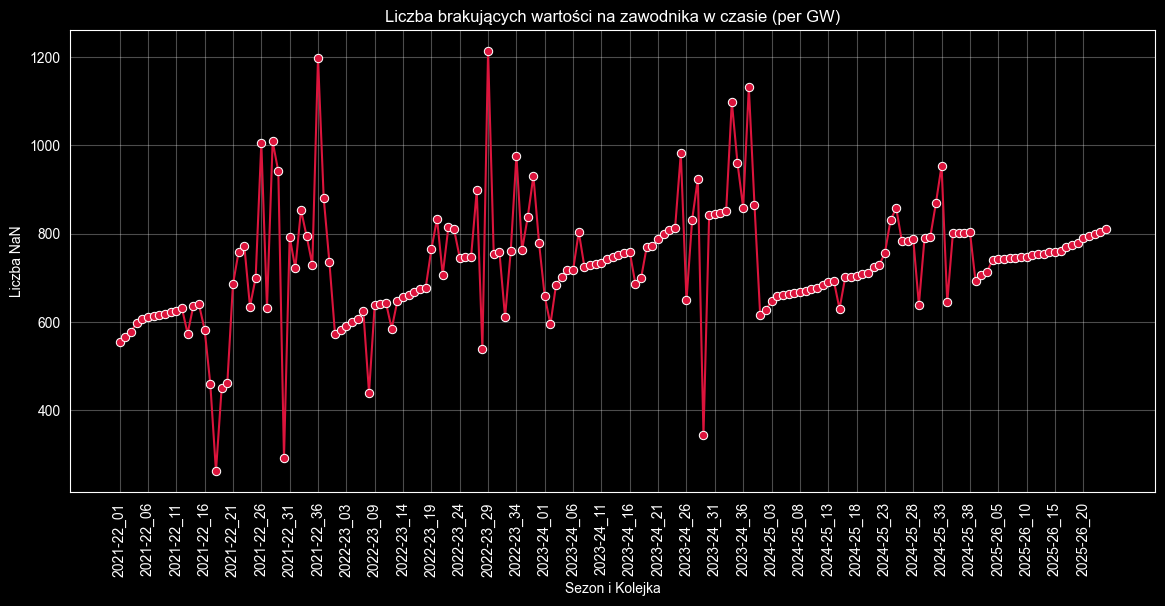

In [10]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=data.isna().sum(axis=1).groupby(data['season_id'].astype(str) + "_" + data['gw'].astype(str).str.zfill(2)).count(),
             color='crimson', marker='o')

plt.title("Liczba brakujących wartości na zawodnika w czasie (per GW)")
plt.ylabel("Liczba NaN")
plt.xlabel("Sezon i Kolejka")

plt.xticks(range(0, data[['season_id', 'gw']].drop_duplicates().shape[0], 5), rotation=90)

plt.grid(alpha=0.3)

In [11]:
data_w_nan = data.copy()

In [12]:
data_w_nan.drop(columns=data_w_nan[s[s>.8].index].columns.to_list(), inplace=True)

In [13]:
data_w_nan = data_w_nan.assign(
    nan_flag = np.where(data_w_nan[s[s < 0.2].index.to_list()].isna().any(axis=1), 1, 0)
)

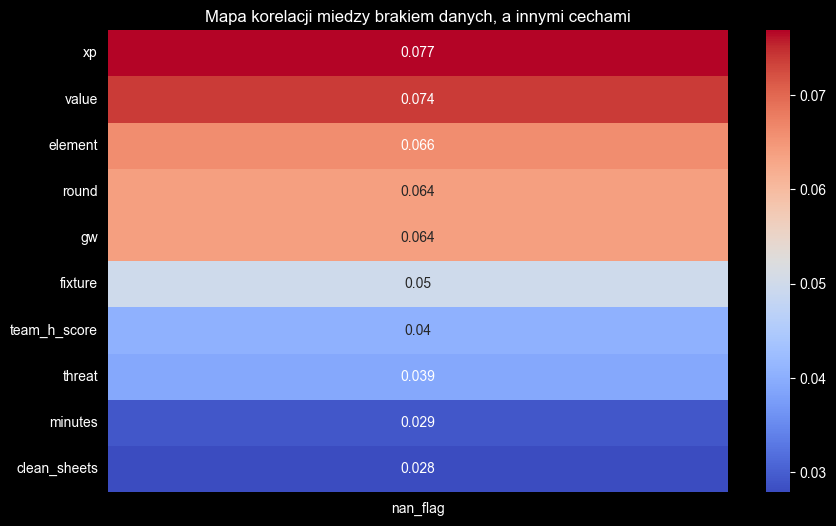

In [14]:
plt.figure(figsize=(10, 6))
plt.title("Mapa korelacji miedzy brakiem danych, a innymi cechami")
sns.heatmap(pd.DataFrame(data_w_nan.drop(columns=data_w_nan.select_dtypes(include=["object", "string"])).corr("pearson")\
                         .nan_flag.apply(np.abs).sort_values(ascending=False).dropna().head(11)).drop(["nan_flag"], axis=0),
            annot=True,
            cmap="coolwarm");

In [15]:
data_w_nan.position.unique()

<ArrowStringArray>
['DEF', 'FWD', 'MID', 'GK', 'GKP', 'AM']
Length: 6, dtype: str

In [16]:
data_w_nan.loc[data_w_nan.position=="GKP", "name"].count()

np.int64(101)

In [17]:
data_w_nan.loc[data_w_nan.position=="GKP"].head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,nan_flag
23828,Bernd Leno,GKP,Arsenal,0.5,0,0,0,0,0.0,1,365,0,0,0.0,0.0,2022-05-16T19:00:00Z,0,14,0,0,0,0,37,0,77632,0,2,0.0,0,-422,216,638,45,False,0,37,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
23855,Nick Pope,GKP,Burnley,8.1,0,0,20,0,0.0,112,367,1,0,4.5,45.0,2022-05-15T11:00:00Z,90,17,0,0,0,0,37,6,320557,0,1,0.0,3,-235,10433,10668,53,False,1,37,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
23856,Nick Pope,GKP,Burnley,8.1,0,1,26,0,0.0,112,171,1,0,5.1,50.8,2022-05-19T19:00:00Z,90,2,0,0,0,0,37,8,320557,1,1,0.0,5,-235,10433,10668,53,False,0,37,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
23859,Will Norris,GKP,Burnley,-1.5,0,0,0,0,0.0,114,367,0,0,0.0,0.0,2022-05-15T11:00:00Z,0,17,0,0,0,0,37,0,9708,0,1,0.0,0,-10,76,86,43,False,0,37,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
23860,Will Norris,GKP,Burnley,-1.5,0,0,0,0,0.0,114,171,0,0,0.0,0.0,2022-05-19T19:00:00Z,0,2,0,0,0,0,37,0,9708,1,1,0.0,0,-10,76,86,43,False,0,37,2021-22,NaN,NaN,NaN,NaN,NaN,None,1


In [18]:
data_w_nan.loc[data_w_nan.position=="GKP"].goals_scored.sum()

np.int64(0)

In [19]:
data_w_nan.position = data_w_nan.position.replace({"GKP" : "GK"})

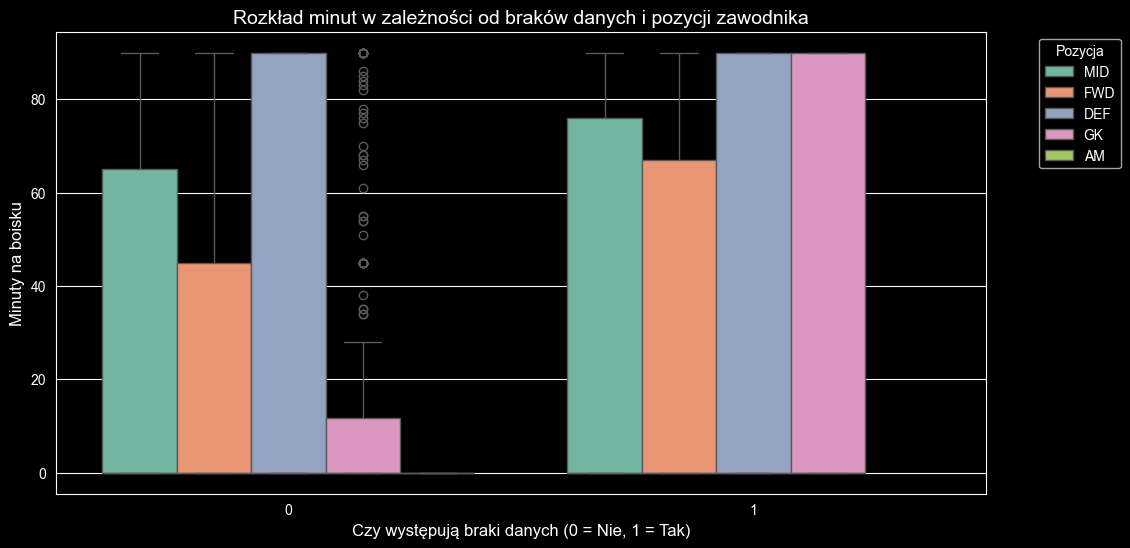

In [20]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data_w_nan,
    x='nan_flag',
    y='minutes',
    hue='position',
    palette='Set2',
    orient="x"

)

plt.title("Rozkład minut w zależności od braków danych i pozycji zawodnika", fontsize=14)
plt.xlabel("Czy występują braki danych (0 = Nie, 1 = Tak)", fontsize=12)
plt.ylabel("Minuty na boisku", fontsize=12)

plt.legend(title='Pozycja', bbox_to_anchor=(1.05, 1), loc='upper left');


In [21]:
data_w_nan[(data_w_nan.position=="GK")]

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,nan_flag
5,Adrián San Miguel del Castillo,GK,Liverpool,2.8,0,0,0,0,0.0,223,7,0,0,0.0,0.0,2021-08-14T16:30:00Z,0,15,0,0,0,0,1,0,17548,3,0,0.0,0,0,0,0,45,False,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
20,Ederson Santana de Moraes,GK,Man City,4.5,0,0,10,0,0.0,257,10,1,0,0.7,6.6,2021-08-15T15:30:00Z,90,17,0,0,0,0,1,1,683423,0,1,0.0,2,0,0,0,60,False,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
49,Kepa Arrizabalaga,GK,Chelsea,3.1,0,0,0,0,0.0,129,3,0,0,0.0,0.0,2021-08-14T14:00:00Z,0,7,0,0,0,0,1,0,19536,0,3,0.0,0,0,0,0,50,True,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
60,Karl Hein,GK,Arsenal,2.0,0,0,0,0,0.0,532,1,0,0,0.0,0.0,2021-08-13T19:00:00Z,0,3,0,0,0,0,1,0,0,0,2,0.0,0,0,0,0,40,False,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
107,Jack Butland,GK,Crystal Palace,1.3,0,0,0,0,0.0,156,3,0,0,0.0,0.0,2021-08-14T14:00:00Z,0,6,0,0,0,0,1,0,30766,0,3,0.0,0,0,0,0,45,False,0,1,2021-22,NaN,NaN,NaN,NaN,NaN,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127432,José Malheiro de Sá,GK,Wolves,2.5,0,0,10,0,0.0,628,240,2,0,2.1,21.0,2026-01-31T15:00:00Z,90,4,0,0,0,0,24,2,138361,2,0,0.0,1,9711,15047,5336,42,True,0,24,2025-26,0.0,0.0,0.0,1.36,1.0,False,0
127433,Callan McKenna,GK,Bournemouth,0.0,0,0,0,0,0.0,69,240,0,0,0.0,0.0,2026-01-31T15:00:00Z,0,20,0,0,0,0,24,0,30755,2,0,0.0,0,155,712,557,39,False,0,24,2025-26,0.0,0.0,0.0,0.00,0.0,False,0
127440,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,0.0,0,0,0,0,0.0,503,237,0,0,0.0,0.0,2026-02-01T14:00:00Z,0,8,0,0,0,0,24,0,8299,1,1,0.0,0,-68,0,68,40,True,0,24,2025-26,0.0,0.0,0.0,0.00,0.0,False,0
127445,Daniel Bentley,GK,Wolves,0.0,0,0,0,0,0.0,629,240,0,0,0.0,0.0,2026-01-31T15:00:00Z,0,4,0,0,0,0,24,0,60709,2,0,0.0,0,403,1057,654,39,True,0,24,2025-26,0.0,0.0,0.0,0.00,0.0,False,0


In [22]:
data_w_nan[data_w_nan.position=="GK"][["expected_assists", "expected_goal_involvements", "expected_goals", "expected_goals_conceded"]].mean()

expected_assists              0.000376
expected_goal_involvements    0.000369
expected_goals                0.000029
expected_goals_conceded       0.328080
dtype: float64

In [23]:
data_w_nan.loc[data_w_nan.position=="GK", ["expected_assists", "expected_goal_involvements", "expected_goals"] ] = data_w_nan.loc[data_w_nan.position=="GK", ["expected_assists", "expected_goal_involvements", "expected_goals"]].fillna(0)

In [24]:
data_w_nan.loc[data_w_nan.position.isin(["GK", "DEF"]), ["name", "position", "team"] + s[s<.2].index.to_list()]

,name,position,team,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts
0,Eric Bailly,DEF,Man Utd,NaN,NaN,NaN,NaN,NaN
5,Adrián San Miguel del Castillo,GK,Liverpool,0.00,0.00,0.00,NaN,NaN
8,Paul Dummett,DEF,Newcastle,NaN,NaN,NaN,NaN,NaN
12,Willy Boly,DEF,Wolves,NaN,NaN,NaN,NaN,NaN
13,José Diogo Dalot Teixeira,DEF,Man Utd,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
127451,Tosin Adarabioyo,DEF,Chelsea,0.00,0.00,0.00,0.00,0.0
127453,Jarrad Branthwaite,DEF,Everton,0.01,0.03,0.02,1.44,1.0
127454,Ethan Pinnock,DEF,Brentford,0.00,0.00,0.00,0.00,0.0
127455,Wellity Lucky,DEF,Liverpool,0.00,0.00,0.00,0.00,0.0


Text(0, 0.5, 'Pozycja')

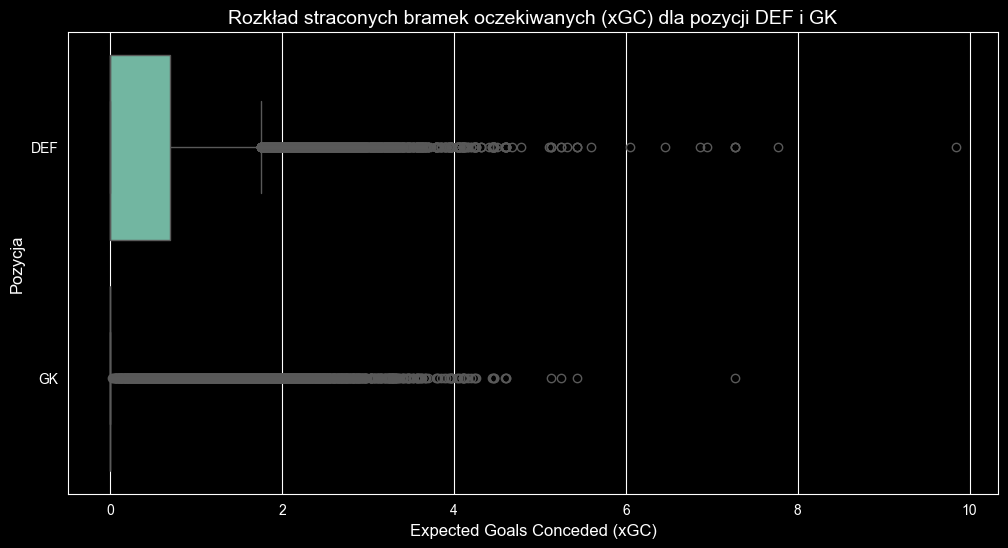

In [25]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data_w_nan[data_w_nan['position'].isin(['DEF', 'GK'])],
    x="expected_goals_conceded",
    y="position",
    hue=data_w_nan[data_w_nan['position'].isin(['DEF', 'GK'])]["position"],
    palette='Set2',
    orient="y"

)

plt.title("Rozkład straconych bramek oczekiwanych (xGC) dla pozycji DEF i GK", fontsize=14)
plt.xlabel("Expected Goals Conceded (xGC)", fontsize=12)
plt.ylabel("Pozycja", fontsize=12)


In [26]:
def pos_imputation(df: pd.DataFrame, cols_to_impute: List[str]) -> pd.DataFrame:
    df = df.copy()

    df[cols_to_impute] = df[cols_to_impute].fillna(
        df.groupby(["season_id", "position", "team"])[cols_to_impute].transform("median")
    )

    df[cols_to_impute] = df[cols_to_impute].fillna(
        df.groupby("position")[cols_to_impute].transform("median")
    )

    return df

In [27]:
cols_to_impute = s[s<.2].index.to_list()
cols_to_impute = [c for c in cols_to_impute if "starts" not in c]
cols_to_impute

['expected_assists',
 'expected_goal_involvements',
 'expected_goals',
 'expected_goals_conceded']

In [28]:
data_w_nan = pos_imputation(df=data_w_nan,
                      cols_to_impute=cols_to_impute)

In [29]:
data_w_nan.expected_goals_conceded.isna().sum()

np.int64(0)

In [30]:
data_w_nan.isna().mean()[data_w_nan.isna().mean()>0]

starts      0.199639
modified    0.640780
dtype: float64

In [31]:
data_w_nan.starts.value_counts(normalize=True)


starts
0.0    0.731714
1.0    0.268286
Name: proportion, dtype: float64

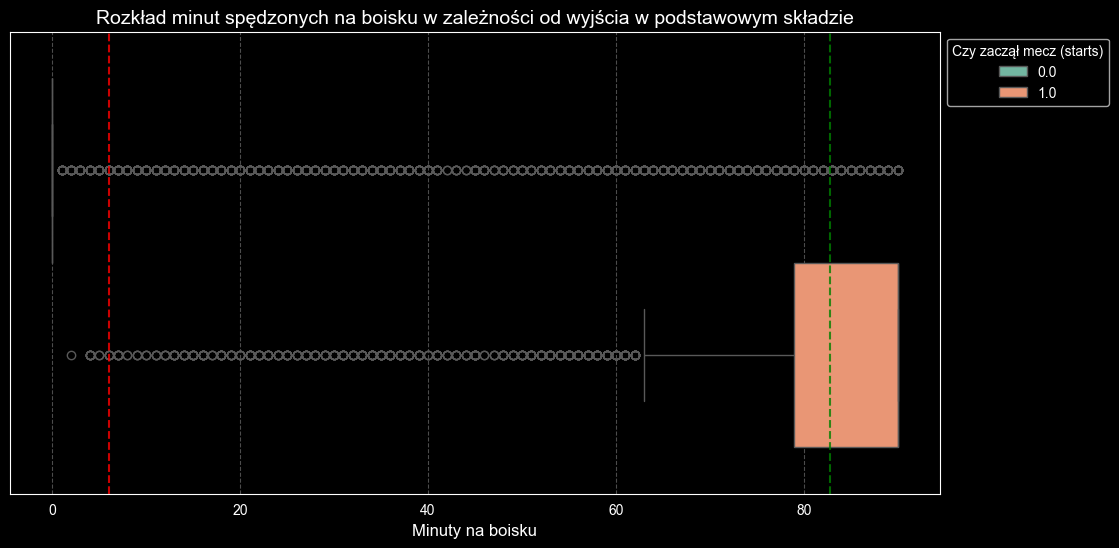

In [32]:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=data_w_nan,
    x="minutes",
    hue="starts",
    palette='Set2'
)

plt.title("Rozkład minut spędzonych na boisku w zależności od wyjścia w podstawowym składzie", fontsize=14)
plt.xlabel("Minuty na boisku", fontsize=12)
sns.move_legend(ax, "upper left", title='Czy zaczął mecz (starts)', bbox_to_anchor=(1, 1))

ax.axvline(x=data_w_nan[data_w_nan.starts==0].minutes.mean(), color='r', linestyle='--', alpha=0.8)
ax.axvline(x=data_w_nan[data_w_nan.starts==1].minutes.mean(), color='g', linestyle='--', alpha=0.8)

plt.grid(axis='x', linestyle='--', alpha=0.3)

In [33]:
data_w_nan[data_w_nan.starts==0].minutes.mean(), data_w_nan[data_w_nan.starts==1].minutes.mean()

(np.float64(6.089674204265352), np.float64(82.73865546218488))

In [34]:
data_w_nan.loc[data.starts.isna(), ["name", "position", "team", "starts", "minutes"]].head()

,name,position,team,starts,minutes
0,Eric Bailly,DEF,Man Utd,NaN,0
1,Keinan Davis,FWD,Aston Villa,NaN,0
2,Ayotomiwa Dele-Bashiru,MID,Watford,NaN,0
3,James Ward-Prowse,MID,Southampton,NaN,90
4,Bruno Miguel Borges Fernandes,MID,Man Utd,NaN,90


In [35]:
[data_w_nan.groupby('team')['starts'].apply(lambda x: x.isna().sum() == 0)]

[team
 Arsenal           False
 Aston Villa       False
 Bournemouth        True
 Brentford         False
 Brighton          False
 Burnley           False
 Chelsea           False
 Crystal Palace    False
 Everton           False
 Fulham             True
 Ipswich            True
 Leeds             False
 Leicester         False
 Liverpool         False
 Luton              True
 Man City          False
 Man Utd           False
 Newcastle         False
 Norwich           False
 Nott'm Forest      True
 Sheffield Utd      True
 Southampton       False
 Spurs             False
 Sunderland         True
 Watford           False
 West Ham          False
 Wolves            False
 Name: starts, dtype: bool]

In [36]:
data_w_nan.loc[data_w_nan['minutes'] == 0, 'starts'] = data_w_nan.loc[data_w_nan['minutes'] == 0, 'starts'].fillna(0)

In [37]:
data_w_nan.starts.isna().mean()

np.float64(0.0822578747107049)

In [38]:
data_w_nan[data_w_nan.starts.isna()]

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,nan_flag
3,James Ward-Prowse,MID,Southampton,2.3,0,0,20,0,30.5,341,4,3,0,5.2,21.6,2021-08-14T14:00:00Z,90,8,0,0,0,0,1,0,299682,1,3,0.0,2,0,0,0,65,False,0,1,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
4,Bruno Miguel Borges Fernandes,MID,Man Utd,4.4,0,3,61,0,35.9,277,6,1,3,20.1,106.2,2021-08-14T11:30:00Z,90,10,0,0,0,0,1,0,3381004,1,5,59.0,20,0,0,0,120,True,0,1,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
6,James McArthur,MID,Crystal Palace,0.5,0,0,22,0,26.0,148,3,3,0,5.5,24.8,2021-08-14T14:00:00Z,90,6,0,0,0,0,1,0,16857,0,3,4.0,2,0,0,0,45,False,0,1,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
9,Jairo Riedewald,MID,Crystal Palace,0.9,0,0,8,0,5.4,157,3,3,0,0.8,2.8,2021-08-14T14:00:00Z,76,6,0,0,0,0,1,0,2741,0,3,0.0,2,0,0,0,50,False,0,1,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
10,Alexis Mac Allister,MID,Brighton,2.4,0,3,28,0,0.4,74,2,0,1,5.6,38.2,2021-08-14T14:00:00Z,14,5,0,0,0,0,1,0,3931,2,1,17.0,9,0,0,0,55,False,0,1,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25437,John Ruddy,GK,Wolves,-0.5,0,0,11,0,0.0,452,378,2,0,0.0,0.0,2022-05-22T15:00:00Z,45,11,0,0,0,0,38,3,15604,1,3,0.0,1,-23,97,120,43,False,0,38,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
25439,Mohammed Salisu,DEF,Southampton,0.4,0,0,13,0,0.0,351,377,4,0,0.0,0.0,2022-05-22T15:00:00Z,90,9,0,0,0,0,38,0,21470,1,4,0.0,0,-131,398,529,45,False,0,38,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
25440,N'Golo Kanté,MID,Chelsea,2.1,0,0,12,0,0.0,130,375,1,0,0.0,0.0,2022-05-22T15:00:00Z,90,18,0,0,0,0,38,0,223561,1,2,0.0,2,-390,2078,2468,49,True,0,38,2021-22,0.0,0.0,0.0,0.0,NaN,None,1
25443,Matt Ritchie,DEF,Newcastle,0.9,0,0,3,0,0.0,292,374,0,0,0.0,0.0,2022-05-22T15:00:00Z,1,5,0,0,0,0,38,0,15999,2,1,0.0,1,143,396,253,49,False,0,38,2021-22,0.0,0.0,0.0,0.0,NaN,None,1


In [39]:
data_w_nan.loc[data_w_nan['starts'].isna(), "starts"] = (data_w_nan['minutes'] > 60).astype(int)

In [40]:
data_w_nan.starts.isna().mean()

np.float64(0.0)

In [41]:
data_w_nan.isna().mean()[data_w_nan.isna().mean()>0]

modified    0.64078
dtype: float64

In [42]:
data_w_nan.dropna(inplace=True)

In [43]:
data_w_nan.isna().sum().sum()

np.int64(0)

In [44]:
data_w_nan.duplicated().sum()

np.int64(10)

In [45]:
data_w_nan[data_w_nan.duplicated()]

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified,nan_flag
109573,Ben Gannon-Doak,MID,Liverpool,0.5,0,0,0,0,0.0,391,1,0,0,0.0,0.0,2025-08-15T19:00:00Z,0,4,0,0,0,0,1,0,4207,2,4,0.0,0,0,0,0,50,True,0,1,2025-26,0.00,0.00,0.00,0.00,0.0,False,0
109920,Junior Kroupi,FWD,Bournemouth,0.0,0,0,2,0,0.0,100,1,1,0,0.0,0.0,2025-08-15T19:00:00Z,1,12,0,0,0,0,1,0,85883,2,4,0.0,1,0,0,0,45,False,0,1,2025-26,0.00,0.00,0.00,0.11,0.0,False,0
110625,Junior Kroupi,FWD,Bournemouth,1.0,0,0,3,0,0.0,100,12,0,0,0.2,0.0,2025-08-23T14:00:00Z,2,20,0,0,0,0,2,0,146695,0,1,2.0,1,28243,48171,19928,45,True,0,2,2025-26,0.00,0.00,0.00,0.06,0.0,False,0
111338,Junior Kroupi,FWD,Bournemouth,1.0,0,0,3,0,0.0,100,29,0,0,0.0,0.0,2025-08-30T14:00:00Z,9,18,0,0,0,0,3,0,130246,1,0,0.0,1,-15048,20512,35560,45,False,0,3,2025-26,0.00,0.00,0.00,0.07,0.0,False,0
112078,Junior Kroupi,FWD,Bournemouth,0.7,0,0,0,0,0.0,100,32,0,0,0.0,0.0,2025-09-13T14:00:00Z,0,6,0,0,0,0,4,0,148264,1,2,0.0,0,8520,38988,30468,45,True,0,4,2025-26,0.00,0.00,0.00,0.00,0.0,False,0
112820,Junior Kroupi,FWD,Bournemouth,-0.2,0,0,0,0,0.0,100,42,0,0,0.0,0.0,2025-09-21T13:00:00Z,0,15,0,0,0,0,5,0,175579,0,0,0.0,0,21660,38996,17336,45,True,0,5,2025-26,0.00,0.00,0.00,0.00,0.0,False,0
113563,Junior Kroupi,FWD,Bournemouth,2.5,0,2,28,0,0.6,100,56,0,1,7.4,35.0,2025-09-27T14:00:00Z,9,11,0,0,0,0,6,0,181004,2,2,38.0,6,3779,29894,26115,45,False,1,6,2025-26,0.00,0.23,0.23,0.07,0.0,False,0
114307,Junior Kroupi,FWD,Bournemouth,0.0,0,0,0,0,0.0,100,63,0,0,0.0,0.0,2025-10-03T19:00:00Z,0,10,0,0,0,0,7,0,205044,1,3,0.0,0,20730,38291,17561,45,True,0,7,2025-26,0.00,0.00,0.00,0.00,0.0,False,0
115053,Junior Kroupi,FWD,Bournemouth,6.0,0,2,59,0,2.6,100,73,2,2,12.7,70.6,2025-10-18T14:00:00Z,74,8,0,0,0,0,8,0,215897,3,3,54.0,12,8066,32682,24616,45,False,0,8,2025-26,0.01,1.19,1.18,2.49,1.0,False,0
115800,Junior Kroupi,FWD,Bournemouth,6.0,0,0,30,1,13.9,100,83,0,1,6.3,32.4,2025-10-26T14:00:00Z,68,16,0,0,0,0,9,0,362815,0,2,17.0,6,136515,153019,16504,45,True,0,9,2025-26,0.06,0.21,0.15,0.14,1.0,False,0


In [46]:
cleaned_cols = data_w_nan.columns.to_list()

In [47]:
data = data_w_nan.drop(columns="nan_flag").copy()

In [48]:
data.shape

(45788, 43)

In [49]:
filename = "../Data/FPL_data_tidy.parquet"
data.to_parquet(filename,
                engine='pyarrow',
                index=False)